# 過学習（Overfitting）

---
## 目的
深層学習における過学習を理解し，その問題に対処するためのアプローチを確認する．

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

### 深層学習と過学習
MLPの教師有り学習における目的は，学習した特徴分布に基づいて未知のデータを正確に予測することです．
しかし，これまでに扱ってきたMLPにおける学習ステップは，既知のデータに対して正確に予測することでした．<br>
つまり，既知のデータへの予測精度を十分高めることが，未知のデータへの予測精度向上につながるとは限りません．
例えば，学習がある程度以上進むと，次第に既知データが持つ，それ自身には意味がないような統計的なばらつきまで学習してしまい，未知データへの予測精度が落ちるという現象である**過学習**が発生してしまいます．<br>
したがって，単に目的関数を訓練データに対して最小化すればよいという問題ではなくなってきます．

次に，こうした過学習への代表的なアプローチをいくつか紹介する．

---
### Regularization （正則化）
過学習が発生する一つの理由は，MLPのモデルは多くのパラメータ・自由度を持つために，訓練データに対して，その本質的な部分以上の統計的ばらつきまで完全にフィットしようと学習してしまうことにあります．
この問題を解決するために，正則化では学習過程でいくつかのパラメータ値を0に近づけています（学習に用いるパラメータを制限する）．
具体的には，損失関数にパラメータの大きさに対するペナルティ項（正則化項）を導入します．これにより, パラメータを自由に動けないように制限し，なるべく少ないパラメータでデータにフィットすることができます．<br>

正則化を含めた損失関数は，モデルのパラメータを表す重み行列$W$，損失関数$J$，正則化項$R$としたとき，次のように定義される：
$$J'=J+\alpha R(W)$$
ここで，$\alpha$は正則化項を調整するパラメータである．<br>

ただし，正則化項は学習時のみに用いて，推論時には含めない選択肢もあります．
なぜなら，正則化項はあくまで学習の都合上導入されたものであるためです．<br>

次に，いくつかの正則化項を紹介する．

---
### L2正則化
L2正則化は，重みの二乗の和に比例する項を正則化項として損失関数に加えます．
L2正則化では，パラメータを完全に0にすることは少ないものの，パラメータを滑らかにすることで予測精度のより良いモデルを構築します．
$$R(W) = \sum_{ij} W_{ij}^{2}$$

**【例】**
下記の目的関数において，任意の初期値$x_0, y_0$から最急勾降下法で$J(x, y)$が最小値となるような最適な値$\hat{x}, \hat{y}$を推定する．
$$J(x, y) = 6x^2 + 3y^2 -8xy$$

---
### L1正則化
L1正則化は，重みの絶対値の和に比例する項を正則化項として損失関数に加えます．
L1正則化では，L2正則化よりもパラメータが0になりやすいという特徴（**スパース性**）があります．
$$R(W) = \sum_{ij} |W_{ij}|$$

---
### ElasticNet
ElasticNet正則化は，L1正則化とL2正則化の組み合わせた項を正則化項として損失関数に加えます．
$$R(W) = \sum_{ij} ( \beta W_{ij}^{2} + (1 - \beta)|W_{ij}|$$

**【Pytorchでの実装例】**
MLPを用いらMNISTデータセットの認識において，損失関数に正則化を導入有/無での比較を確認する．<br>

In [15]:
# GPUが利用可能かどうかを確認
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Epochsの設定
if torch.cuda.is_available():
    num_epochs = 20
else:
    num_epochs = 5
print(f"Epochs: {num_epochs}")

Using device: cuda
Epochs: 20


1. DataLoaderの定義<br>
まずMNISTデータセットを"./dataset"にダウンロードします．
そして，学習/テストのおいてそれぞれDataLoaderを定義します．

In [16]:
# データの前処理
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# MNISTデータセットのダウンロード
train_dataset = torchvision.datasets.MNIST(root='./dataset', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./dataset', train=False, transform=transform, download=True)

# DataLoaderの作成
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

2. MLPモデルの定義<br>
今回は畳み込み層2層，全結合層2層の合計4層のCNNを定義します．<br>

In [17]:
# 畳み込みニューラルネットワークの定義
class CNNWithRegularization(nn.Module):
    def __init__(self):
        super(CNNWithRegularization, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.view(-1, 64 * 7 * 7)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x
    

3. 学習，推論の定義<br>
損失関数に正則化項を加えます．そのため，学習ステップのみに正則化項の計算処理を加えます．

In [18]:
def train(model, train_loader, optimizer, criterion, regularization_type=None, regularization_strength=0.001, epochs=5):
    train_losses = []  # トレーニング損失を記録
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)

            # 通常の損失
            loss = criterion(outputs, labels)

            # 正則化項の追加
            if regularization_type == "L1":
                l1_regularization = 0.0
                for param in model.parameters():
                    l1_regularization += torch.norm(param, p=1)
                loss += regularization_strength * l1_regularization
            elif regularization_type == "L2":
                l2_regularization = 0.0
                for param in model.parameters():
                    l2_regularization += torch.norm(param, p=2)
                loss += regularization_strength * l2_regularization

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss}')

    return train_losses

# テスト関数
def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    # print(f'Test Accuracy: {accuracy}')
    return accuracy

4. モデルの学習と評価<br>
正則化項の有無での学習の過程およびテストデータに対する評価を行います．

Training without regularization:
Epoch [1/20], Loss: 0.1541261769685227
Epoch [2/20], Loss: 0.04347337020321815
Epoch [3/20], Loss: 0.03123869848513811
Epoch [4/20], Loss: 0.021792890596356036
Epoch [5/20], Loss: 0.017298317282588124
Epoch [6/20], Loss: 0.013039529686941376
Epoch [7/20], Loss: 0.011225596989498841
Epoch [8/20], Loss: 0.00965300092008665
Epoch [9/20], Loss: 0.007721168605125008
Epoch [10/20], Loss: 0.006243457536241902
Epoch [11/20], Loss: 0.005993076953211269
Epoch [12/20], Loss: 0.005633190529692547
Epoch [13/20], Loss: 0.004923473735601374
Epoch [14/20], Loss: 0.004074164113134642
Epoch [15/20], Loss: 0.0045330737014199355
Epoch [16/20], Loss: 0.00333431758395695
Epoch [17/20], Loss: 0.004033367018452894
Epoch [18/20], Loss: 0.004160826456663788
Epoch [19/20], Loss: 0.00399308545743533
Epoch [20/20], Loss: 0.0021377702445386335

Training with L1 regularization:
Epoch [1/20], Loss: 0.354852617771895
Epoch [2/20], Loss: 0.18317314325524037
Epoch [3/20], Loss: 0.1520155

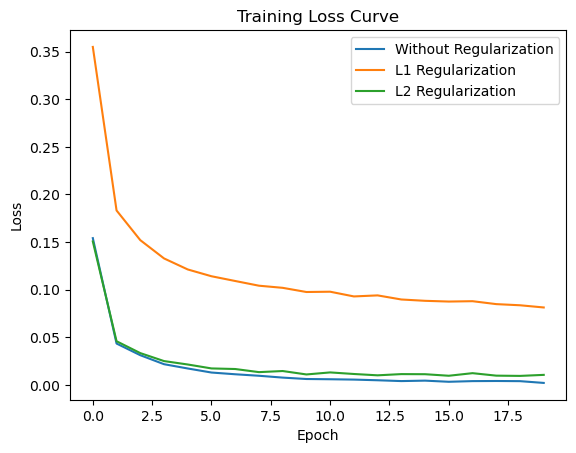

Test Accuracy (w/o R) : 0.9908
Test Accuracy (w/  L1) : 0.9894
Test Accuracy (w/  L2) : 0.9917


In [19]:
criterion = nn.CrossEntropyLoss()

# トレーニング (正則化なし)
print("Training without regularization:")
model = CNNWithRegularization().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses_without_regularization = train(model, train_loader, optimizer, criterion, epochs=num_epochs)
test_accuracy_without_regularization = test(model, test_loader)

# トレーニング (L1正則化)
print("\nTraining with L1 regularization:")
model = CNNWithRegularization().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses_with_l1_regularization = train(model, train_loader, optimizer, criterion, regularization_type="L1", 
                                            regularization_strength=0.0001, epochs=num_epochs)
test_accuracy_with_l1_regularization = test(model, test_loader)

# トレーニング (L2正則化)
print("\nTraining with L2 regularization:")
model = CNNWithRegularization().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train_losses_with_l2_regularization = train(model, train_loader, optimizer, criterion, regularization_type="L2", 
                                            regularization_strength=0.0001, epochs=num_epochs)
test_accuracy_with_l2_regularization = test(model, test_loader)


def plot_learning_curve(train_losses, label):
    plt.plot(train_losses, label=label)

plot_learning_curve(train_losses_without_regularization, label='Without Regularization')
plot_learning_curve(train_losses_with_l1_regularization, label='L1 Regularization')
plot_learning_curve(train_losses_with_l2_regularization, label='L2 Regularization')
# 学習曲線をプロット
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()

print(f'Test Accuracy (w/o R) : {test_accuracy_without_regularization}')
print(f'Test Accuracy (w/  L1) : {test_accuracy_with_l1_regularization}')
print(f'Test Accuracy (w/  L2) : {test_accuracy_with_l2_regularization}')


---
### Dropout（ドロップアウト）
過学習の原因のひとつは，統計的なばらつきを余計に学習していることにあります．
このような確率的なばらつきは，一般的に大量のデータを集約すると相殺される傾向にあります．
このテクニックは，訓練データセットから部分訓練データセットを大量に作成し，各モデルの予測結果を平均する**アンサンブル**という手法に応用されています．
しかし，このアンサンブル法は，とてつもない計算量を要するためそのまま用いることは困難です．<br>
そこで深層学習では，**ドロップアウト (dropout)*と呼ばれる近似的にアンサンブル法を実現する手法が提案されています．
具体的には，学習中にネットワーク内のランダムなユニット（ニューロン）を無効にすることで，異なるサブネットワークをトレーニングすることを意味します．これにより多数のモデルを同時に訓練することと同じ効果を再現し，モデルはより頑健で一般化された特徴を学習することが期待されます．

ドロップアウトの数学的な表現：
**（学習）**<br>
ネットワーク内の各ユニット（ニューロン）に対して、確率$p$で無効にする二値単数変数$r_{i}$を導入します．ユニット$i$の出力を$o_{i}$，無効になる確率を$p$とすると，学習時には次のようにドロップアウトが適用されます：
$$o^{(train)}=r_{i}\cdot o^{(original)}$$
ここで，$o^{(train)}$はドロップアウトを考慮した出力，$o^{(original)}$は通常のネットワーク出力である．<br>

**（テスト）**<br>
推論時には，通常ドロップアウトを適用せず，すべてのユニットを用いて予測します．
ただし，学習時と同じ重みで結果を予測するために，推論時には各ニューロンのウェイトに$(1−p)$を掛けます．
$$o^{(test)}=(1-p)\cdot o^{(original)}$$

**【Pytorchでの実装例】**
MLPを用いらMNISTデータセットの認識において，ドロップアウトを導入有/無での比較を確認する．<br>

Using device: cuda
Training without dropout:
Epoch [1/20], Loss: 0.31165394227085974
Epoch [2/20], Loss: 0.14099296157174845
Epoch [3/20], Loss: 0.10581586936385488
Epoch [4/20], Loss: 0.08471594399947331
Epoch [5/20], Loss: 0.07465647937328335
Epoch [6/20], Loss: 0.06306563195527227
Epoch [7/20], Loss: 0.05743684119513648
Epoch [8/20], Loss: 0.04982950036718782
Epoch [9/20], Loss: 0.047772948733537886
Epoch [10/20], Loss: 0.04121984286940714
Epoch [11/20], Loss: 0.039205945668809576
Epoch [12/20], Loss: 0.03353138191118548
Epoch [13/20], Loss: 0.03261472126084895
Epoch [14/20], Loss: 0.03122263737411962
Epoch [15/20], Loss: 0.02816318381859274
Epoch [16/20], Loss: 0.026722409790739227
Epoch [17/20], Loss: 0.026192286617783105
Epoch [18/20], Loss: 0.025228165810706398
Epoch [19/20], Loss: 0.021249303584787597
Epoch [20/20], Loss: 0.024319536659333455

Training with dropout:
Epoch [1/20], Loss: 0.35557726717420984
Epoch [2/20], Loss: 0.1888090985209576
Epoch [3/20], Loss: 0.150836930965

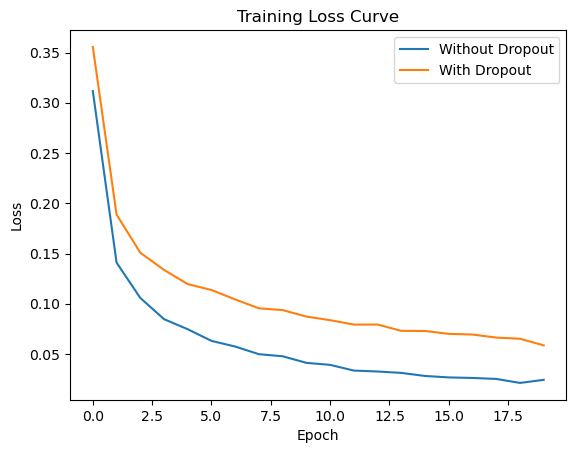

Test Accuracy (w/o D) : 0.9779
Test Accuracy (w/  D) : 0.9779


In [21]:
# GPUが利用可能かどうかを確認
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ドロップアウトを導入したニューラルネットワークの定義
class NeuralNetworkWithDropout(nn.Module):
    def __init__(self, dropout_prob=0.5):
        super(NeuralNetworkWithDropout, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_prob)
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        x = x.view(-1, 28 * 28)
        x = self.relu(self.fc1(x))
        if self.training:
            x = self.dropout(x)
        else:
            x *= (1.0 - self.dropout.p)
        x = self.fc2(x)
        return x

# トレーニング関数
def train(model, train_loader, optimizer, criterion, epochs=5):
    train_losses = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f'Epoch [{epoch + 1}/{epochs}], Loss: {avg_loss}')
    return train_losses

# テスト関数
def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = correct / total
    # print(f'Test Accuracy: {accuracy}')
    return accuracy

# 学習曲線をプロットする関数
def plot_learning_curve(train_losses, label):
    plt.plot(train_losses, label=label)

# モデル、損失関数、最適化手法の定義
model_without_dropout = NeuralNetworkWithDropout(dropout_prob=0.0).to(device)
model_with_dropout = NeuralNetworkWithDropout(dropout_prob=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_without_dropout = optim.Adam(model_without_dropout.parameters(), lr=0.001)
optimizer_with_dropout = optim.Adam(model_with_dropout.parameters(), lr=0.001)

# トレーニング (ドロップアウトなし)
print("Training without dropout:")
train_losses_without_dropout = train(model_without_dropout, train_loader, optimizer_without_dropout, criterion, epochs=num_epochs)
test_accuracy_without_dropout = test(model_without_dropout, test_loader)
plot_learning_curve(train_losses_without_dropout, label='Without Dropout')

# トレーニング (ドロップアウトあり)
print("\nTraining with dropout:")
train_losses_with_dropout = train(model_with_dropout, train_loader, optimizer_with_dropout, criterion, epochs=num_epochs)
test_accuracy_with_dropout = test(model_with_dropout, test_loader)
plot_learning_curve(train_losses_with_dropout, label='With Dropout')

# 学習曲線をプロット
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.show()

print(f'Test Accuracy (w/o D) : {test_accuracy_without_dropout}')
print(f'Test Accuracy (w/  D) : {test_accuracy_with_dropout}')